In [1]:
import pandas as pd
import fsspec
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

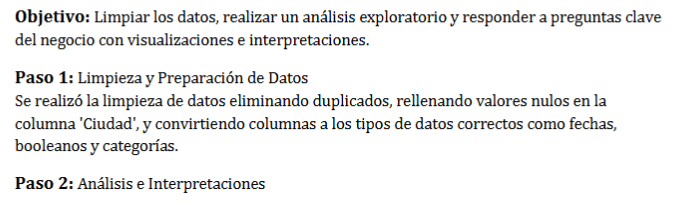

# 0. Tratamiento de Datos

In [3]:
url = "https://raw.githubusercontent.com/kevin19925/modulo5/31d3a23df48b1679c899d38ac212ee490d0bcaef/ventas_tienda.csv"
df = pd.read_csv(url, header=0)
print(df.head())

                               ID_Venta       Fecha      Hora    Producto  \
0  9405d7f0-a4fd-4085-b884-fb79a25652a0  2025-04-04  07:33:04         few   
1  3370585d-2830-4e98-ac1f-b7d09956ea1e  2025-01-30  02:55:33    painting   
2  ec4a8759-62c6-4c61-b678-17bf8d654910  2025-04-04  10:35:15  commercial   
3  afd66fea-ffa3-4d0a-9b60-768d10df78e4  2025-03-18  01:51:20      myself   
4  26d5a020-ee04-407d-937c-95558bbe6db3  2025-01-18  20:07:13          TV   

   Categoría  Precio_Unitario  Cantidad  Total_Venta      Método_Pago  \
0      Hogar           287.05         9      2583.45   Tarjeta Débito   
1       Ropa           292.82         9      2635.38  Tarjeta Crédito   
2      Hogar            26.59         1        26.59   Tarjeta Débito   
3  Alimentos           436.26         5      2181.30           PayPal   
4     Libros           206.97         8      1655.76   Tarjeta Débito   

   Nombre_Cliente  ... Cupón_Usado Código_Cupón Forma_Contacto  \
0   Rachel Miller  ...          

In [6]:
df.head()

,ID_Venta,Fecha,Hora,Producto,Categoría,Precio_Unitario,Cantidad,Total_Venta,Método_Pago,Nombre_Cliente,...,Cupón_Usado,Código_Cupón,Forma_Contacto,Comentarios_Cliente,Estado_Venta,ID_Cliente,ID_Empleado,Fecha_Registro_Cliente,Edad_Cliente,Genero_Cliente
0,9405d7f0-a4fd-4085-b884-fb79a25652a0,2025-04-04,07:33:04,few,Hogar,287.05,9,2583.45,Tarjeta Débito,Rachel Miller,...,Sí,gaDgpk,Llamada,Necessary environmental already sure themselves.,En Proceso,f8e8b8c1-8a54-4ca3-924c-522192536fca,2d745288-a4a3-4e1a-a22b-936cc1b888b0,2020-08-19,39,Masculino
1,3370585d-2830-4e98-ac1f-b7d09956ea1e,2025-01-30,02:55:33,painting,Ropa,292.82,9,2635.38,Tarjeta Crédito,Donald Johnson,...,No,IbhcYU,Email,Skin pick source admit sometimes can.,En Proceso,3c6fa3d2-e182-4a0e-9497-7ee319ea3dbc,4ea029f8-bc7b-4b10-86c2-95db550f4512,2025-02-10,27,Femenino
2,ec4a8759-62c6-4c61-b678-17bf8d654910,2025-04-04,10:35:15,commercial,Hogar,26.59,1,26.59,Tarjeta Débito,Evelyn Collins,...,No,EoFbeq,Llamada,Performance agent wonder hear employee purpose...,Cancelada,7f7adff3-7292-4349-b41c-6e24645a4ef9,9ae64380-c984-401e-bfce-d5740695ddf2,2021-01-20,69,Masculino
3,afd66fea-ffa3-4d0a-9b60-768d10df78e4,2025-03-18,01:51:20,myself,Alimentos,436.26,5,2181.30,PayPal,Melissa Clark,...,Sí,HHsbwN,Email,Though bad seem small herself hospital score.,Cancelada,0795e45d-1524-44bd-a375-8468ede86302,6ae76204-1359-478f-bc93-516301f188af,2023-10-25,42,Otro
4,26d5a020-ee04-407d-937c-95558bbe6db3,2025-01-18,20:07:13,TV,Libros,206.97,8,1655.76,Tarjeta Débito,James Mora,...,Sí,IsTYXt,Llamada,Your approach plan Mrs north.,En Proceso,4e54c429-523f-45ae-9171-cc2dc03895ae,3bcc4621-5bab-4fdb-90de-018aa2a1c876,2023-01-11,20,Masculino


Conversion de tipos , categorical

In [38]:
# categorical ventas
df["Categoría"]=pd.Categorical(df["Categoría"])
df["Método_Pago"]=pd.Categorical(df["Método_Pago"])

#fecha
df["Fecha"]=pd.to_datetime(df["Fecha"],format="%Y-%m-%d")
df["Fecha_Registro_Cliente"]=pd.to_datetime(df["Fecha_Registro_Cliente"],format="%Y-%m-%d")
df["Hora"]=pd.to_datetime(df["Hora"])



Rellenar valores nulos

In [14]:
df_cuidad_nula=df.loc[df["Ciudad"].isna()]
# df_cuidad_nula[["Ciudad","Producto"]]
df["Ciudad"] = df["Ciudad"].fillna("Desconocido")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_Venta                500 non-null    object        
 1   Fecha                   500 non-null    datetime64[ns]
 2   Hora                    500 non-null    datetime64[ns]
 3   Producto                500 non-null    object        
 4   Categoría               500 non-null    category      
 5   Precio_Unitario         500 non-null    float64       
 6   Cantidad                500 non-null    int64         
 7   Total_Venta             500 non-null    float64       
 8   Método_Pago             500 non-null    category      
 9   Nombre_Cliente          500 non-null    object        
 10  Correo_Cliente          500 non-null    object        
 11  Teléfono_Cliente        500 non-null    object        
 12  Ciudad                  500 non-null    object    

# Preguntas
## 1. Que categoria genera mas ingresos?

In [16]:
df_categoriaIngresos=df.groupby("Categoría")["Total_Venta"].sum()
df_categoriaIngresos


/tmp/ipykernel_14711/888969147.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_categoriaIngresos=df.groupby("Categoría")["Total_Venta"].sum()


,Total_Venta
Categoría,
Accesorios,99074.78
Alimentos,86498.24
Electrónica,100444.12
Hogar,109849.26
Juguetes,88381.48
Libros,120832.25
Ropa,94295.92


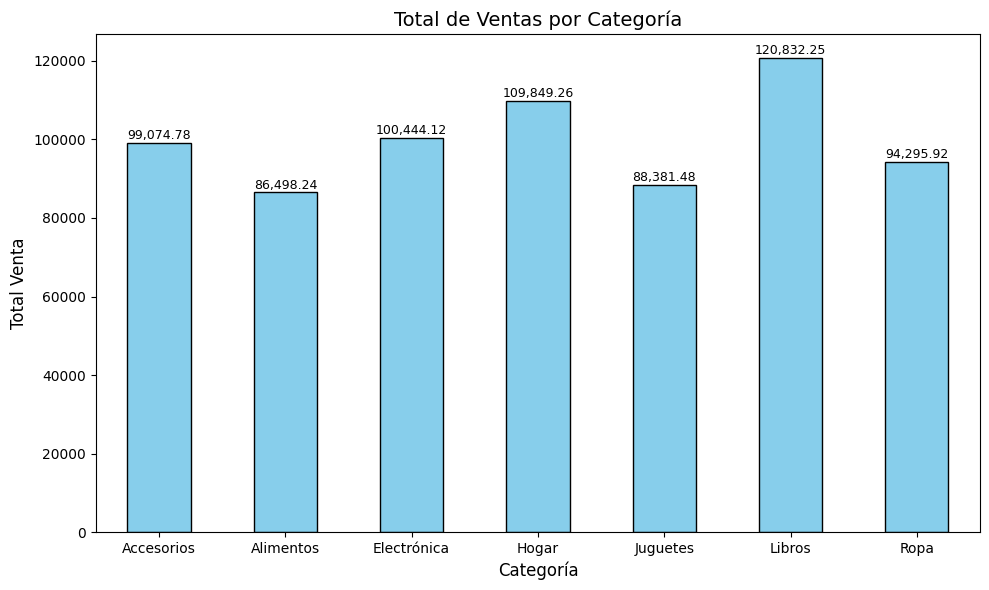

In [18]:
# Gráfico de barras a partir del Series
plt.figure(figsize=(10,6))
df_categoriaIngresos.plot(kind="bar", color="skyblue", edgecolor="black")

# Títulos y etiquetas
plt.title("Total de Ventas por Categoría", fontsize=14)
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Total Venta", fontsize=12)
plt.xticks(rotation=0) # rotacion si son muchas categorias

# Mostrar valores encima de cada barra
for i, v in enumerate(df_categoriaIngresos):
    plt.text(i, v + 1000, f"{v:,.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


Concluimos que la categoria que mas vende es la de `libros`

# 2. Metodo de Pago mas usado



In [19]:
df_met_pago=df.groupby("Método_Pago")["ID_Venta"].count()
df_met_pago

/tmp/ipykernel_14711/2649877317.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_met_pago=df.groupby("Método_Pago")["ID_Venta"].count()


,ID_Venta
Método_Pago,
Efectivo,121
PayPal,97
Tarjeta Crédito,96
Tarjeta Débito,105
Transferencia,81


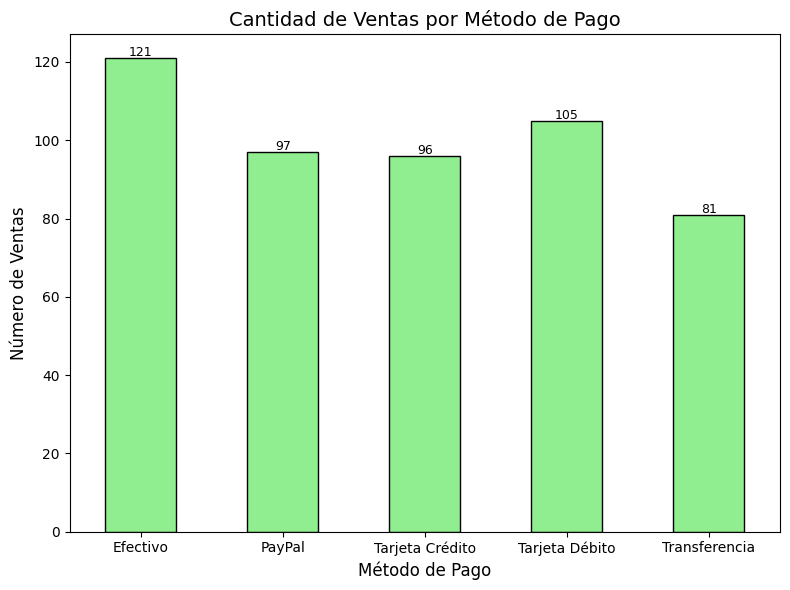

In [21]:
import matplotlib.pyplot as plt

# Gráfico de barras para métodos de pago
plt.figure(figsize=(8,6))
df_met_pago.plot(kind="bar", color="lightgreen", edgecolor="black")

# Títulos y etiquetas
plt.title("Cantidad de Ventas por Método de Pago", fontsize=14)
plt.xlabel("Método de Pago", fontsize=12)
plt.ylabel("Número de Ventas", fontsize=12)
plt.xticks(rotation=0)

# Mostrar valores encima de cada barra
for i, v in enumerate(df_met_pago):
    plt.text(i, v + 0.5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


concluimos que el metodo de pago mas usado es `efectivo`

# 3. Distribucion Edad

<!-- creamos nuestra propia columna -->


In [22]:
## categorizaremos un valor numerico por rangos
df_edades=df.copy()

def clasificarEdad(edad):
    if edad < 12:
        return "menor de 12"
    elif edad >= 12 and edad < 18:
        return "adolescente"
    elif edad >= 18 and edad < 30:
        return "adulto joven"
    elif edad >= 30 and edad < 60:
        return "adulto"
    else:
        return "adulto mayor"


df_edades["edad_rango"] = df_edades["Edad_Cliente"].apply(clasificarEdad)


In [23]:
## eliminamos duplicados para la columna de clientes ya que no queremos repeticiones

print(f"clientes con todas las ventas: {len(df_edades)}")

df_edades["ID_Cliente"].drop_duplicates()

print(f"clientes unicos: {len(df_edades)}")



clientes con todas las ventas: 500
clientes unicos: 500


In [28]:
# notamos que no hay clientes repetidos en cada venta

df_edades_Cat=df_edades.groupby("edad_rango")["ID_Venta"].count().reset_index()
df_edades_Cat

,edad_rango,ID_Venta
0,adulto,273
1,adulto joven,106
2,adulto mayor,121


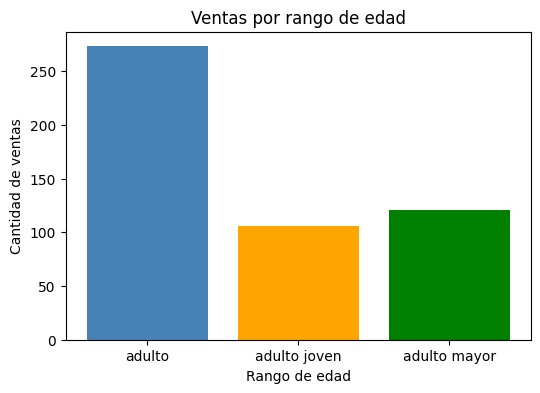

In [30]:
# Gráfico de barras
plt.figure(figsize=(6,4))
plt.bar(df_edades_Cat["edad_rango"], df_edades_Cat["ID_Venta"], color=["steelblue","orange","green"])
plt.title("Ventas por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de ventas")
plt.show()


# hitograma

# plt.figure(figsize=(6,4))
# plt.hist(df_edades["edad_rango"], bins=3, color="steelblue", rwidth=0.8)
# plt.title("Histograma de ventas por rango de edad")
# plt.xlabel("Rango de edad")
# plt.ylabel("Frecuencia")
# plt.show()

# 4. Correlacion
## Existe alguna relacion de precion y cantidad vendida?

In [34]:
corr_precio_cantidad=df[["Cantidad","Precio_Unitario"]].corr()
# df[["Cantidad","Precio_Unitario"]].head()
corr_precio_cantidad


,Cantidad,Precio_Unitario
Cantidad,1.000000,0.001409
Precio_Unitario,0.001409,1.000000


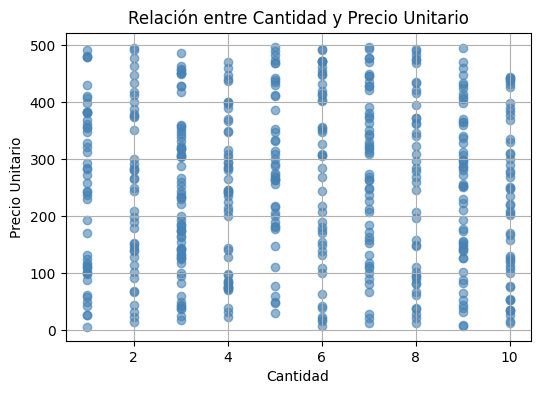

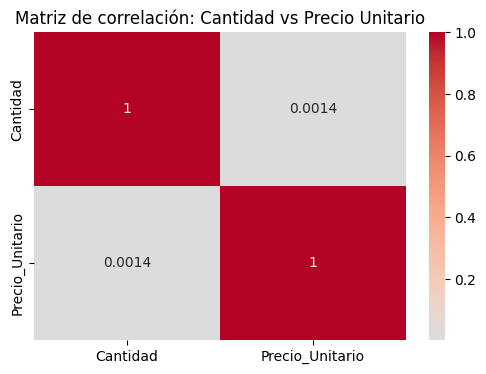

In [36]:

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df["Cantidad"], df["Precio_Unitario"], alpha=0.6, color="steelblue")
plt.title("Relación entre Cantidad y Precio Unitario")
plt.xlabel("Cantidad")
plt.ylabel("Precio Unitario")
plt.grid(True)
plt.show()

# Heatmap

# plt.figure(figsize=(6,4))
# sns.heatmap(corr_precio_cantidad, annot=True, cmap="coolwarm", center=0)
# plt.title("Matriz de correlación: Cantidad vs Precio Unitario")
# plt.show()

**Vemos que en este caso no hay relacion entre precio y cantidad vendida**

# 5 Clientes nuevo vs Frecuentes

 ## Los clientes nuevos compran mas que los clientes frecuentes



In [49]:
# analizamos cual es la ultima fecha registrada
df["Fecha_Registro_Cliente"] = pd.to_datetime(df["Fecha_Registro_Cliente"], errors="coerce")
ultima_fecha = df["Fecha_Registro_Cliente"].max()
print(f"Fecha última registrada: {ultima_fecha}")


Fecha última registrada: 2025-04-16 00:00:00


In [58]:

## para este analicis crearemos otra columna para categorizar si es nuevo cliente o viejo

def cat_Cliente(fecha_registro):
  if((ultima_fecha-fecha_registro).days<=30):
    return "Nuevo cliente"
  else:
    return "Conocido cliente"

df["cat_cliente"]=df["Fecha_Registro_Cliente"].apply(cat_Cliente)


df["cat_cliente"].head()


,cat_cliente
0,Conocido cliente
1,Conocido cliente
2,Conocido cliente
3,Conocido cliente
4,Conocido cliente


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_Venta                500 non-null    object        
 1   Fecha                   500 non-null    datetime64[ns]
 2   Hora                    500 non-null    datetime64[ns]
 3   Producto                500 non-null    object        
 4   Categoría               500 non-null    category      
 5   Precio_Unitario         500 non-null    float64       
 6   Cantidad                500 non-null    int64         
 7   Total_Venta             500 non-null    float64       
 8   Método_Pago             500 non-null    category      
 9   Nombre_Cliente          500 non-null    object        
 10  Correo_Cliente          500 non-null    object        
 11  Teléfono_Cliente        500 non-null    object        
 12  Ciudad                  500 non-null    object    

In [60]:
df_clientes=df["ID_Cliente"].value_counts()
df_clientes

,count
ID_Cliente,
1905a7a6-21d0-4d16-baea-d932a891cc0e,1
f8e8b8c1-8a54-4ca3-924c-522192536fca,1
3c6fa3d2-e182-4a0e-9497-7ee319ea3dbc,1
7f7adff3-7292-4349-b41c-6e24645a4ef9,1
8cadc3ec-61de-4c51-a60b-37c41b21ee31,1
...,...
6edb269f-407a-4b8b-8477-4192928c603f,1
d42c921e-29cf-4163-bbd3-4505a5490bd1,1
70d8ceaf-33bd-486e-97b9-ddb19c0ebb7c,1


In [55]:
df_clienteFrecuencia=df.groupby("cat_cliente")["ID_Venta"].count()
df_clienteFrecuencia

,ID_Venta
cat_cliente,
Conocido cliente,493
Nuevo cliente,7


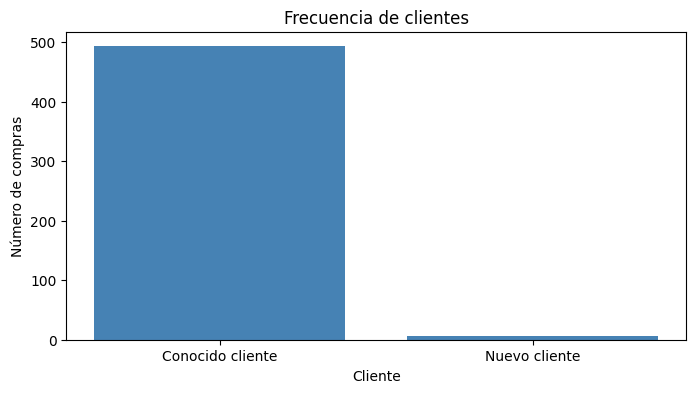

In [61]:

# Supongamos que df_clienteFrecuencia tiene columnas: Cliente y Frecuencia
plt.figure(figsize=(8,4))
plt.bar(df_clienteFrecuencia.index, df_clienteFrecuencia.values, color="steelblue")
plt.title("Frecuencia de clientes")
plt.xlabel("Cliente")
plt.ylabel("Número de compras")
# plt.xticks(rotation=45)
plt.show()


**como vimos anterior mente , los clientes no se repiten en este dataframe , por lo que la uncia pregunta que se pudo responder es cuantos clientes son nuevos y no nuevos**


# 6 Clasificacion por porvincia



In [71]:
df_provincias=df.groupby("Provincia")["ID_Venta"].count()
# print(len(df_provincias.tail()))
df_provincias

,ID_Venta
Provincia,
Alabama,9
Alaska,5
Arizona,8
Arkansas,7
California,9
Colorado,12
Connecticut,7
Delaware,7
Florida,16


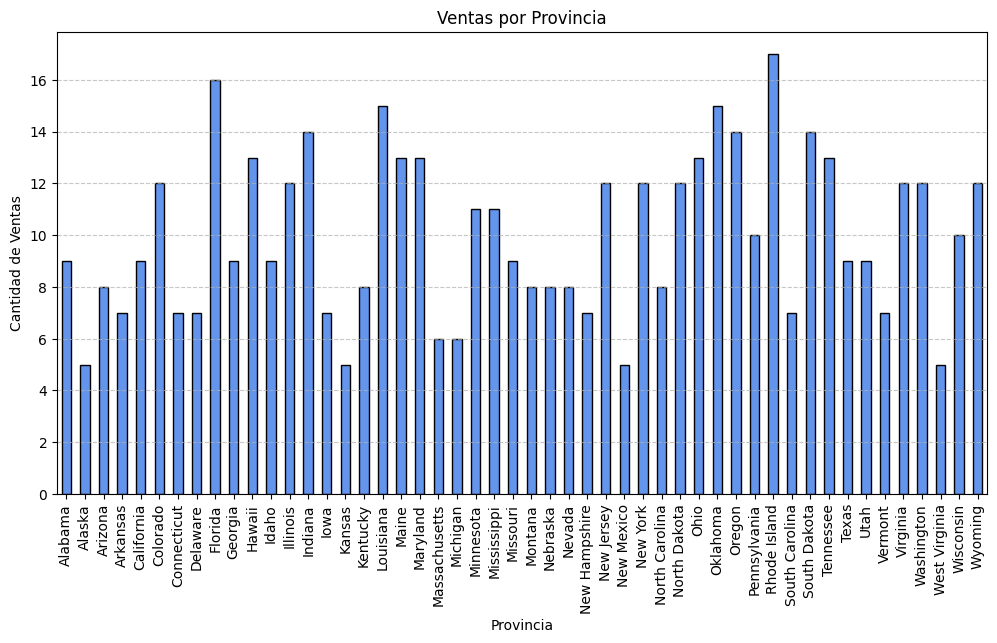

In [66]:

plt.figure(figsize=(12,6))
df_provincias.plot(kind="bar", color="cornflowerblue", edgecolor="black")
plt.title("Ventas por Provincia")
plt.xlabel("Provincia")
plt.ylabel("Cantidad de Ventas")
plt.xticks(rotation=90)  # gira etiquetas para que se lean mejor
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [68]:

# # Agrupar ventas por provincia
# df_provincias = df.groupby("Provincia")["ID_Venta"].count()

# # Calcular media y mediana
# media = df_provincias.mean()
# mediana = df_provincias.median()

# # Grafico de barras
# plt.figure(figsize=(12,6))
# df_provincias.plot(kind="bar", color="cornflowerblue", edgecolor="black")

# # Líneas de referencia
# plt.axhline(media, color="red", linestyle="--", linewidth=2, label=f"Media ({media:.2f})")
# plt.axhline(mediana, color="green", linestyle=":", linewidth=2, label=f"Mediana ({mediana:.2f})")


# plt.title("Ventas por Provincia con Media y Mediana")
# plt.xlabel("Provincia")
# plt.ylabel("Cantidad de Ventas")
# plt.xticks(rotation=90)
# plt.legend()
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.show()


In [80]:
df_provincias = df.groupby("Provincia")["Calificación_Cliente"].mean()
df_provincias = df_provincias.sort_values(ascending=False)
# print(df_provincias)


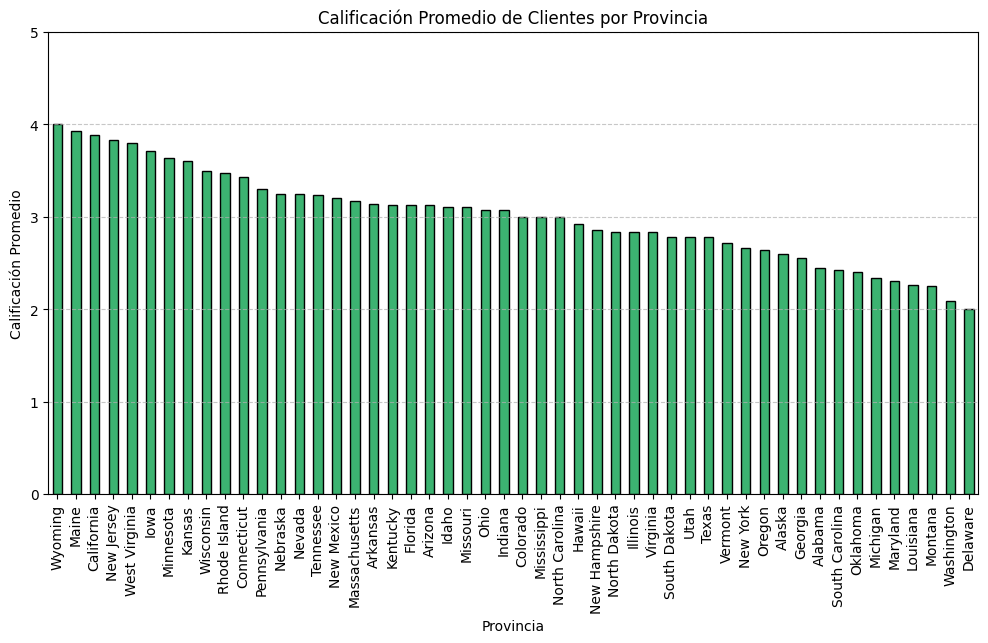

In [81]:

plt.figure(figsize=(12,6))
df_provincias.plot(kind="bar", color="mediumseagreen", edgecolor="black")
plt.title("Calificación Promedio de Clientes por Provincia")
plt.xlabel("Provincia")
plt.ylabel("Calificación Promedio")
plt.xticks(rotation=90)
plt.ylim(0, 5)  # escala de calificación
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


**la conclusion de este grafico es estudiar , el servicio al cliente en los mejores estados y obserbar o interferir en los menos calificados**

# 7. Top 10 empleados por Ventas
## cuales son los mejores 10?



In [85]:
df_empleados=df.groupby("Empleado_Vendedor")["Total_Venta"].sum()
df_empleados.sort_values(ascending=False)
## iloc recibe numeros de registros
df_mejores10=df_empleados.iloc[0:10]
df_mejores10

,Total_Venta
Empleado_Vendedor,
Aaron Gomez,2629.34
Aaron Juarez,115.04
Aaron Lowe,3797.84
Aaron Miller,1064.46
Aaron Walsh,760.00
Adam Miranda,407.88
Adrian Gonzales,991.88
Alejandro Delacruz,130.56
Alex Carroll DVM,2981.04


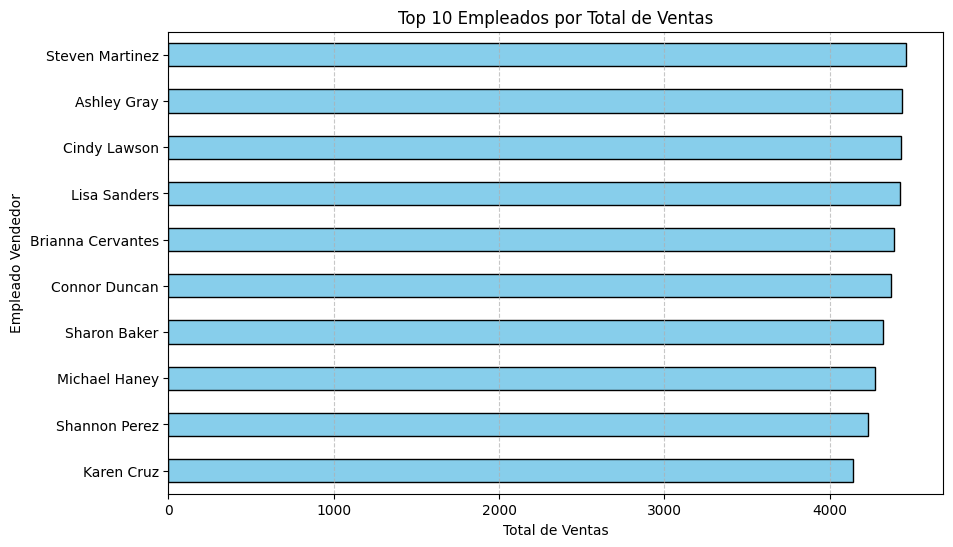

In [86]:

# Agrupar ventas por empleado
df_empleados = df.groupby("Empleado_Vendedor")["Total_Venta"].sum()

# Ordenar y seleccionar top 10
df_empleados = df_empleados.sort_values(ascending=False)
df_mejores10 = df_empleados.iloc[0:10]

# Gráfico de barras horizontal
plt.figure(figsize=(10,6))
df_mejores10.sort_values().plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Top 10 Empleados por Total de Ventas")
plt.xlabel("Total de Ventas")
plt.ylabel("Empleado Vendedor")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


**los 10 mejores esta respondida , ahora hay que incentivar a los mejores y en observacion o capacitacion a los demas, pero para ser mas justo seria de promediar en un mes**

# 8 estado de entrega


In [87]:
# Estado_Entrega
df_estadoEntre=df.groupby("Estado_Entrega")["ID_Venta"].count()
df_estadoEntre

,ID_Venta
Estado_Entrega,
En camino,176
Entregado,184
Pendiente,140


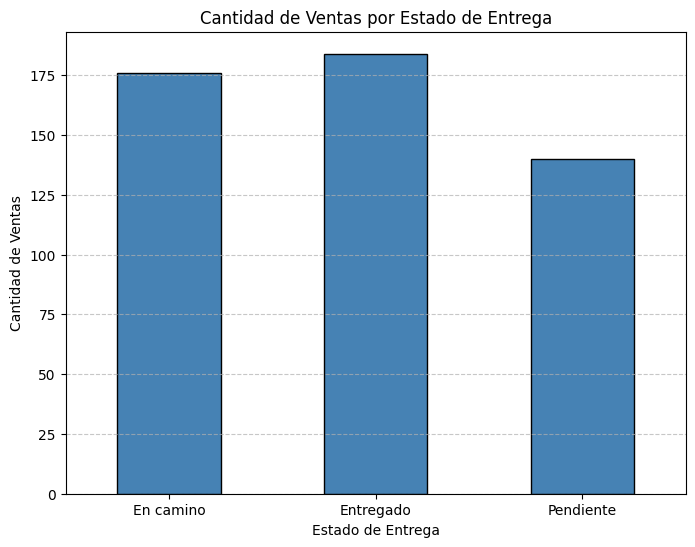

In [88]:

# Agrupar ventas por estado de entrega
df_estadoEntre = df.groupby("Estado_Entrega")["ID_Venta"].count()

# Gráfico de barras
plt.figure(figsize=(8,6))
df_estadoEntre.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Cantidad de Ventas por Estado de Entrega")
plt.xlabel("Estado de Entrega")
plt.ylabel("Cantidad de Ventas")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


# 9. Ventas con cupones

In [89]:
df["Cupón_Usado"].value_counts()

,count
Cupón_Usado,
Sí,283
No,217


In [92]:
df_VentasCupones = df.groupby("Cupón_Usado").agg({
    "ID_Venta": "count",
    "Total_Venta": "sum"
})
print(df_VentasCupones)


             ID_Venta  Total_Venta
Cupón_Usado                       
No                217    286859.76
Sí                283    412516.29


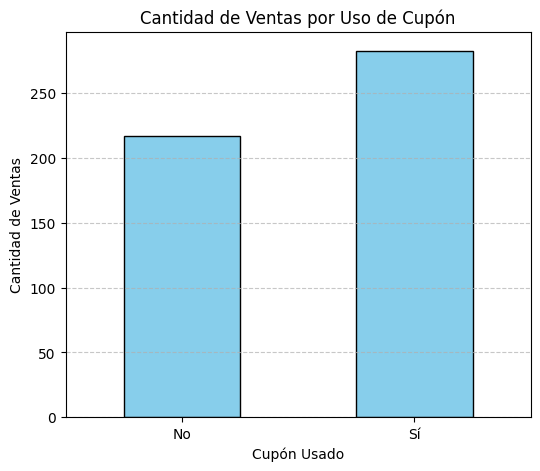

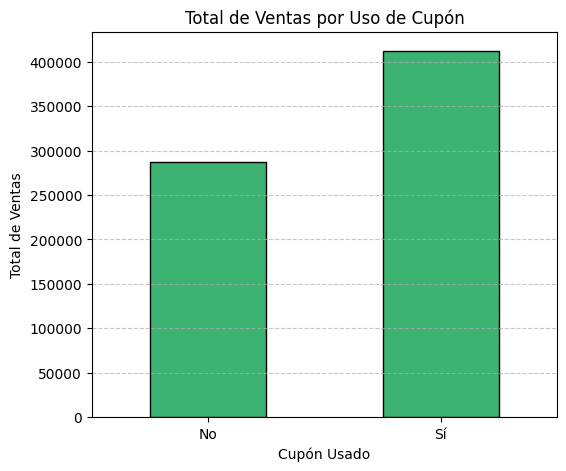

In [93]:
import matplotlib.pyplot as plt

# Agrupar datos
df_VentasCupones = df.groupby("Cupón_Usado").agg({
    "ID_Venta": "count",
    "Total_Venta": "sum"
})

# Gráfico 1: Cantidad de ventas
plt.figure(figsize=(6,5))
df_VentasCupones["ID_Venta"].plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Cantidad de Ventas por Uso de Cupón")
plt.xlabel("Cupón Usado")
plt.ylabel("Cantidad de Ventas")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Gráfico 2: Total de ventas
plt.figure(figsize=(6,5))
df_VentasCupones["Total_Venta"].plot(kind="bar", color="mediumseagreen", edgecolor="black")
plt.title("Total de Ventas por Uso de Cupón")
plt.xlabel("Cupón Usado")
plt.ylabel("Total de Ventas")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


**Observamos que las ventas con cupones son mayores**

# 10 Distribuvion de calificaciones


In [94]:
df_distribucion=df.groupby("Calificación_Cliente")["ID_Venta"].count()
df_distribucion




,ID_Venta
Calificación_Cliente,
1,110
2,92
3,94
4,96
5,108


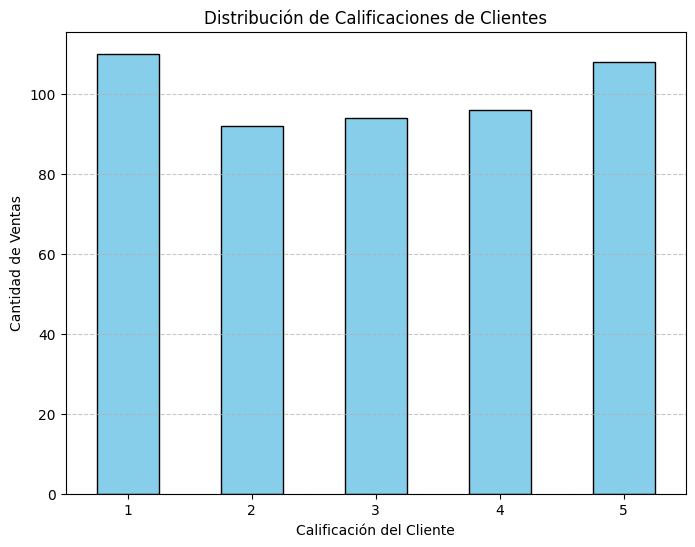

In [95]:
z_scores=stats.zscore(df["Calificación_Cliente"])

plt.figure(figsize=(8,6))
df_distribucion.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribución de Calificaciones de Clientes")
plt.xlabel("Calificación del Cliente")
plt.ylabel("Cantidad de Ventas")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


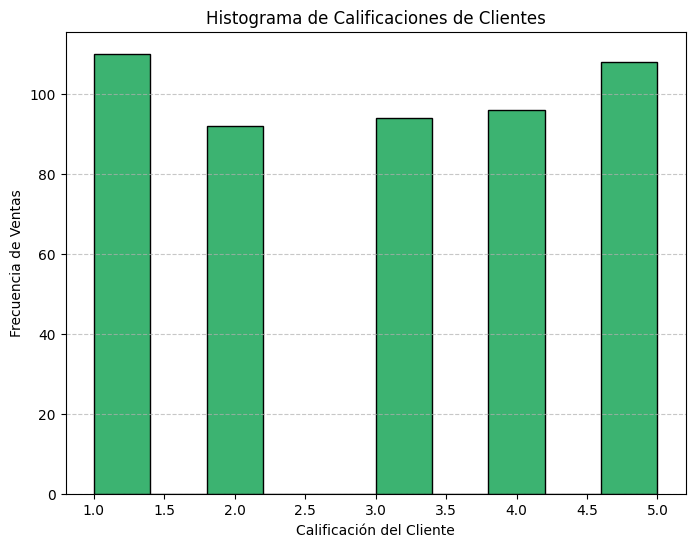

In [96]:
plt.figure(figsize=(8,6))
plt.hist(df["Calificación_Cliente"], bins=10, color="mediumseagreen", edgecolor="black")
plt.title("Histograma de Calificaciones de Clientes")
plt.xlabel("Calificación del Cliente")
plt.ylabel("Frecuencia de Ventas")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
